## Setup 
Load the two audio sources, import libs, etc

In [8]:
from scipy import signal
from scipy.fft import fft, ifft
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
# from impulseest import impulseest


rate_classical, classical_raw = wavfile.read('guitar_sounds/Classical_1.wav')
rate_steel, steel_raw = wavfile.read('guitar_sounds/Steel_1.wav')

classical_note = classical_raw[:, 0]
steel_note = steel_raw[:, 0]

number_samples = len(classical1)
assert len(steel1) == number_samples, 'input files need to have the same number of samples'
print(rate_classical)
assert rate_classical == rate_steel, 'audio file sample rates must match'

44100


/tmp/ipykernel_26836/946107070.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_classical, classical_raw = wavfile.read('guitar_sounds/Classical_1.wav')
/tmp/ipykernel_26836/946107070.py:10: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_steel, steel_raw = wavfile.read('guitar_sounds/Steel_1.wav')


# Attempt 1
Trying to directly generate the IR and apply it to the source without any preprocessing. Works at least sort of well enough, but leaves a lot to be desired.

/tmp/ipykernel_26836/369664686.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


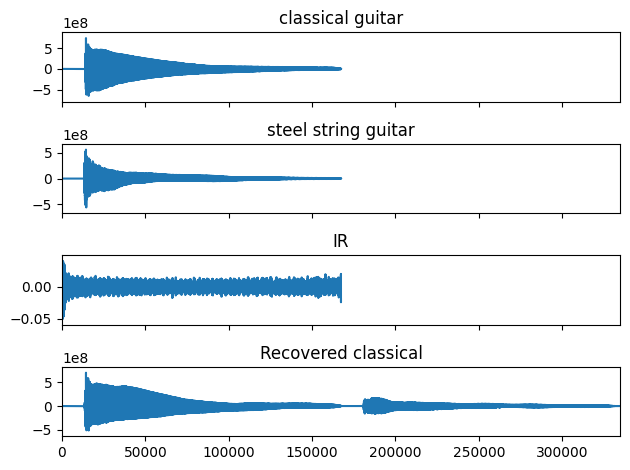

In [12]:
steel_fft = fft(steel_note)
classical_fft = fft(classical_note)

H = classical_fft / steel_fft

ir = ifft(H).real[:number_samples]

modeled_classical = signal.convolve(steel_note, ir)

fig, (ax_orig, ax_win, ax_filt, ax_rec) = plt.subplots(4, 1, sharex=True)
ax_orig.plot(classical_note)
ax_orig.set_title('classical guitar')
ax_orig.margins(0, 0.1)
ax_win.plot(steel_note)
ax_win.set_title('steel string guitar')
ax_win.margins(0, 0.1)
ax_filt.plot(ir)
ax_filt.set_title('IR')
ax_filt.margins(0, 0.1)
ax_rec.plot(modeled_classical)
ax_rec.set_title('Recovered classical')
ax_rec.margins(0, 0.1)
fig.tight_layout()
fig.show()

from IPython.display import display, Audio
display(Audio(modeled_classical, rate=44100, autoplay=False))

# Preprocessing to do IR stuff 
Works about as well? I think maybe doing this with the sweep data would work well.

/tmp/ipykernel_26836/356128166.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


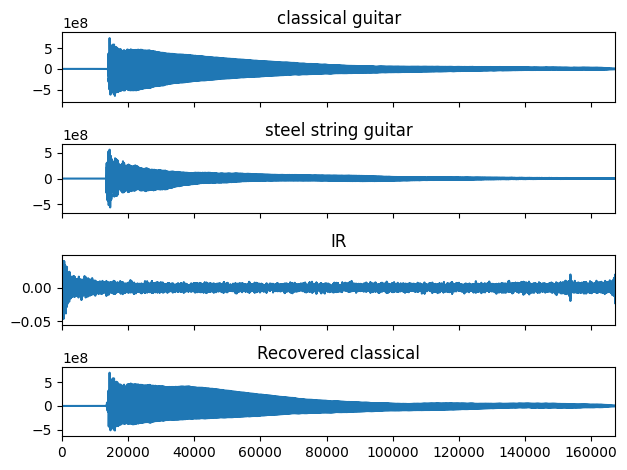

In [18]:
# get rid of preceeding zeros 
shortened_steel = np.trim_zeros(steel_note, 'f')
shortened_classical = np.trim_zeros(classical_note, 'f')

# make sure the two are the same length
shorter_sample_length = min(len(shortened_classical), len(shortened_steel))
shortened_steel = shortened_steel[:shorter_sample_length]
shortened_classical = shortened_classical[:shorter_sample_length]


assert len(shortened_classical) == len(shortened_steel), f'processed note lengths don\'t match, steel is {len(shortened_steel)} samples, classical is {len(shortened_classical)} samples'

steel_fft = fft(shortened_steel)
classical_fft = fft(shortened_classical)

H = classical_fft / steel_fft

ir = ifft(H).real[:number_samples]

modeled_classical = signal.convolve(shortened_steel, ir)[:shorter_sample_length]

fig, (ax_orig, ax_win, ax_filt, ax_rec) = plt.subplots(4, 1, sharex=True)
ax_orig.plot(shortened_classical)
ax_orig.set_title('classical guitar')
ax_orig.margins(0, 0.1)
ax_win.plot(shortened_steel)
ax_win.set_title('steel string guitar')
ax_win.margins(0, 0.1)
ax_filt.plot(ir)
ax_filt.set_title('IR')
ax_filt.margins(0, 0.1)
ax_rec.plot(modeled_classical)
ax_rec.set_title('Recovered classical')
ax_rec.margins(0, 0.1)
fig.tight_layout()
fig.show()

from IPython.display import display, Audio
display(Audio(shortened_classical, rate=44100, autoplay=False))
display(Audio(shortened_steel, rate=44100, autoplay=False))
display(Audio(modeled_classical, rate=44100, autoplay=False))